Getting a medical insurance covers has been important for individuals because health risks are increasing rapidly. With the rise of insurance comes the need to forecast medical cost to ensure the insurance companies formulates policies that covers for the risk but still remain profitable. Customers on the other side need to know their medical expenses to budget for that and to optimize coverage that is not to pay for preimum covers which they end up not using or paying for low cover which forces them to get back to their pockets. Given factors like smoking, region and others we are going to build a model that predicts the medical cost prices


1. Age:
Age is a significant factor in health insurance as older individuals are generally at a higher risk of health issues compared to younger individuals.
Therefore, age often correlates with higher insurance charges.

2. Sex:
Gender can play a role in health insurance costs. Some studies suggest that women tend to use more health care services, especially during childbearing years.
However, the impact of gender on health insurance charges can vary depending on other factors.

3. BMI (Body Mass Index):
BMI is a measure that attempts to quantify an individual's tissue mass.
It's widely used as a simple method to assess whether a person has a healthy body weight for a given height.
High BMI values are often associated with higher risk of chronic diseases, which can lead to higher health care costs.

4. Children:
The number of dependents a person has can influence health insurance costs.
More dependents usually mean higher insurance charges because more individuals are covered under the same plan.

5. Smoker:
Smoking is a significant risk factor for many health conditions, including heart disease, stroke, and cancer.
Smokers often face higher health insurance charges due to these increased health risks.

6. Region:
The region where the beneficiary lives can also affect health insurance charges.
This could be due to variations in cost of living, health care costs, and health behaviors across different regions.

7. Charges:
This is the individual medical costs billed by health insurance.
It's the dependent variable in this dataset, and it's influenced by all the other factors.
Understanding the relationships between the independent variables (age, sex, bmi, children, smoker, region) and charges is the main goal of this analysis.

In [1]:
## import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import SelectKBest, f_regression,mutual_info_regression
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor,ExtraTreesRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
## load the dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mosapabdelghany/medical-insurance-cost-dataset")

print("Path to dataset files:", path)

100%|██████████| 16.0k/16.0k [00:00<00:00, 4.78MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mosapabdelghany/medical-insurance-cost-dataset/versions/1


In [3]:
df = pd.read_csv(f'{path}/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
## number of recorded patients
df.shape

(1338, 7)

In [5]:
## check the data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
## check missingness
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [7]:
## check for duplicates
df.duplicated().sum()

np.int64(1)

In [8]:
df.loc[df.duplicated(keep = False), :]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [9]:
df.drop_duplicates(inplace = True)

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


In [11]:
df.describe(include = 'O').T

,count,unique,top,freq
sex,1337,2,male,675
smoker,1337,2,no,1063
region,1337,4,southeast,364


Observations:
- The dataset contains a record of 1338 patients with 7 features
- The dataset is complete(no missing values)
- The dataset contains one duplicate
- Male are the majority recorded patients in the dataset
- Patients from southeast region are the majority
- Max number of children is 5 while max age of the the patients is 64

In [12]:
num_cols = df.select_dtypes(include = 'number').columns.to_list()
cat_cols = df.select_dtypes(include = 'object').columns.to_list()

print(cat_cols)
print(num_cols)

['sex', 'smoker', 'region']
['age', 'bmi', 'children', 'charges']


**EDA**

Numerical Analysis

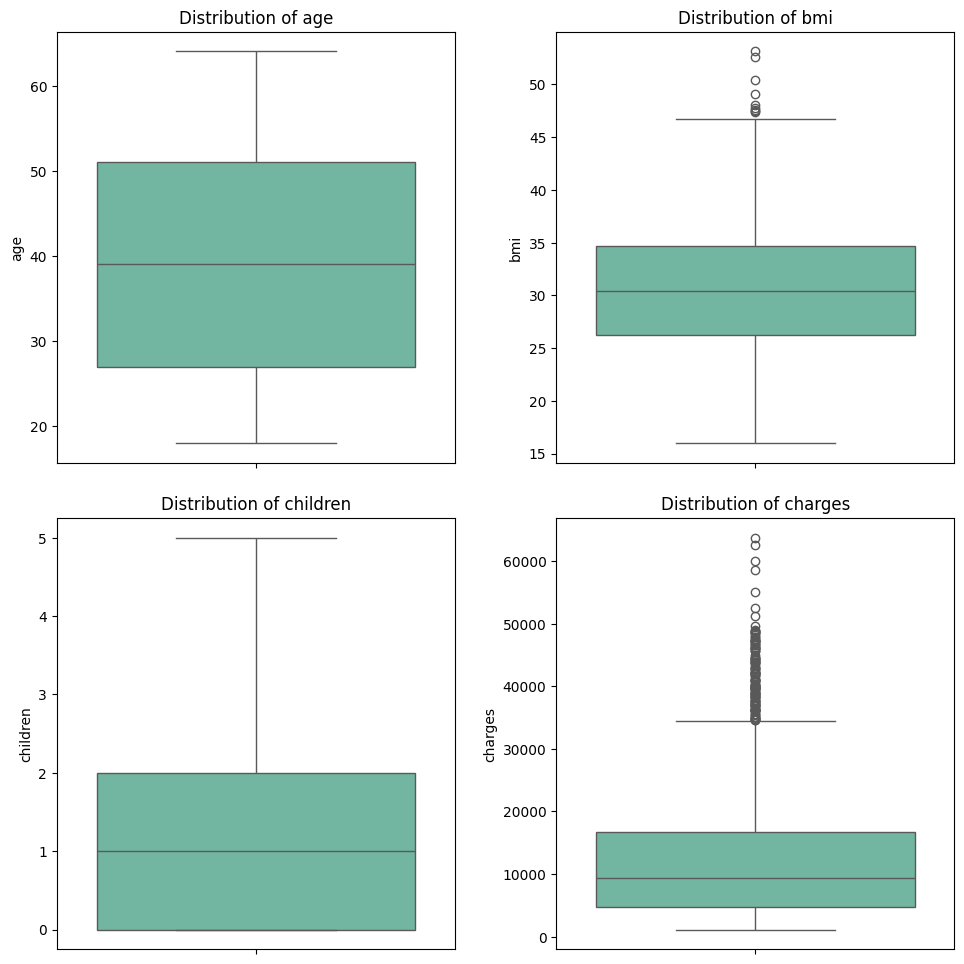

In [13]:
plt.figure(figsize = (10,10))
for i, col in  enumerate(num_cols):
  plt.subplot(2,2,i+1)
  sns.boxplot(df[col], palette = 'Set2')
  plt.title(f'Distribution of {col}')
  plt.tight_layout(pad = 2)
plt.show()

Observe Charges and BMI columns have some extreme values but this are useful values for our analysis so we are not going to cap them

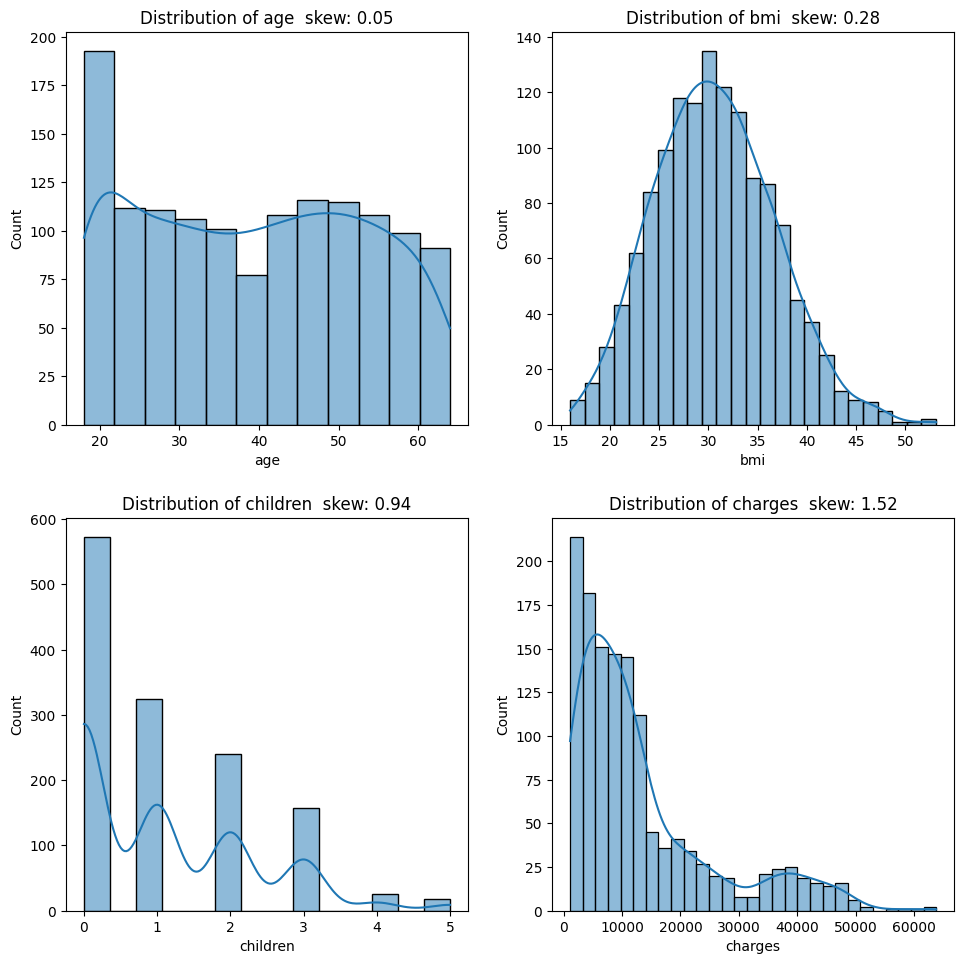

In [14]:
plt.figure(figsize = (10,10))
for i, col in  enumerate(num_cols):
  plt.subplot(2,2,i+1)
  sns.histplot(df[col], kde = True, palette = 'Set2')
  plt.title(f'Distribution of {col}  skew: {df[col].skew():.2f}')
  plt.tight_layout(pad = 2)
plt.show()

Children and Charges columns are skew to the right. Where as BMI and age are normally distributed

Numerical vs Target

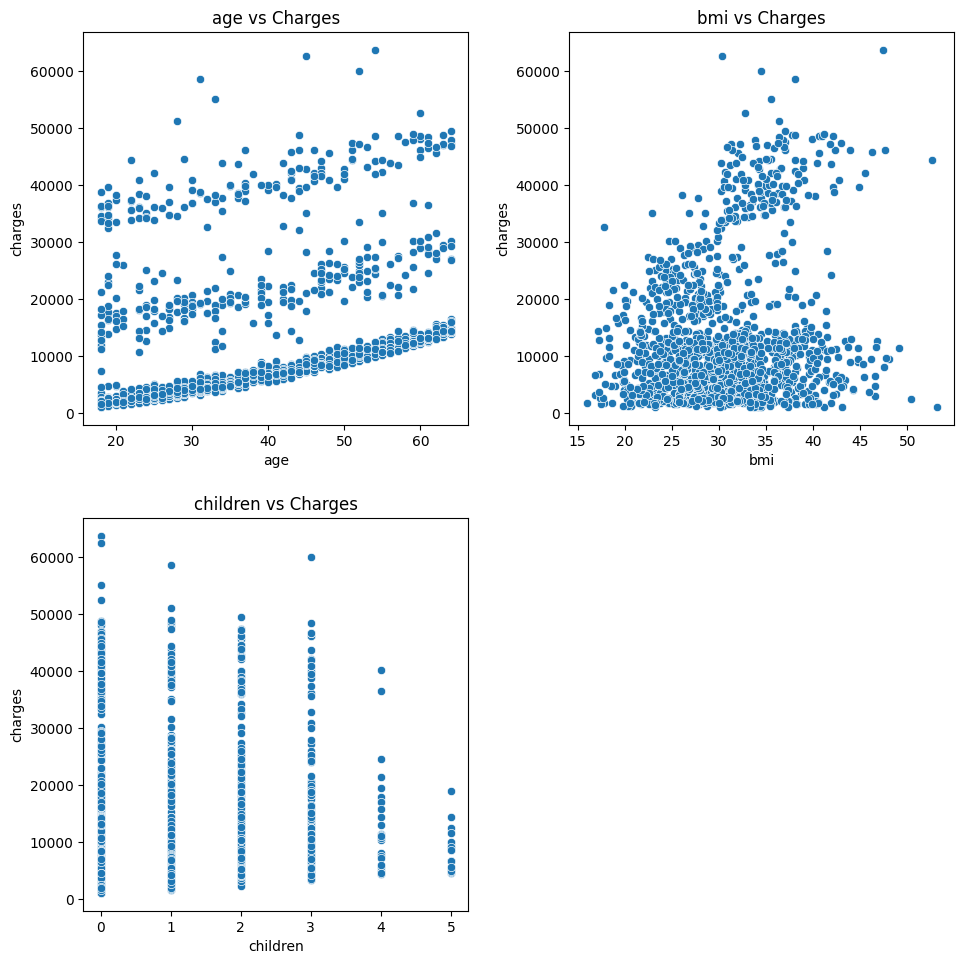

In [15]:
plt.figure(figsize = (10,10))
for i, col in  enumerate(['age', 'bmi', 'children']):
  plt.subplot(2,2,i+1)
  sns.scatterplot(x = df[col], y = df['charges'], palette = 'Set2')
  plt.title(f'{col} vs Charges')
  plt.tight_layout(pad = 2)
plt.show()

Categorical Analysis

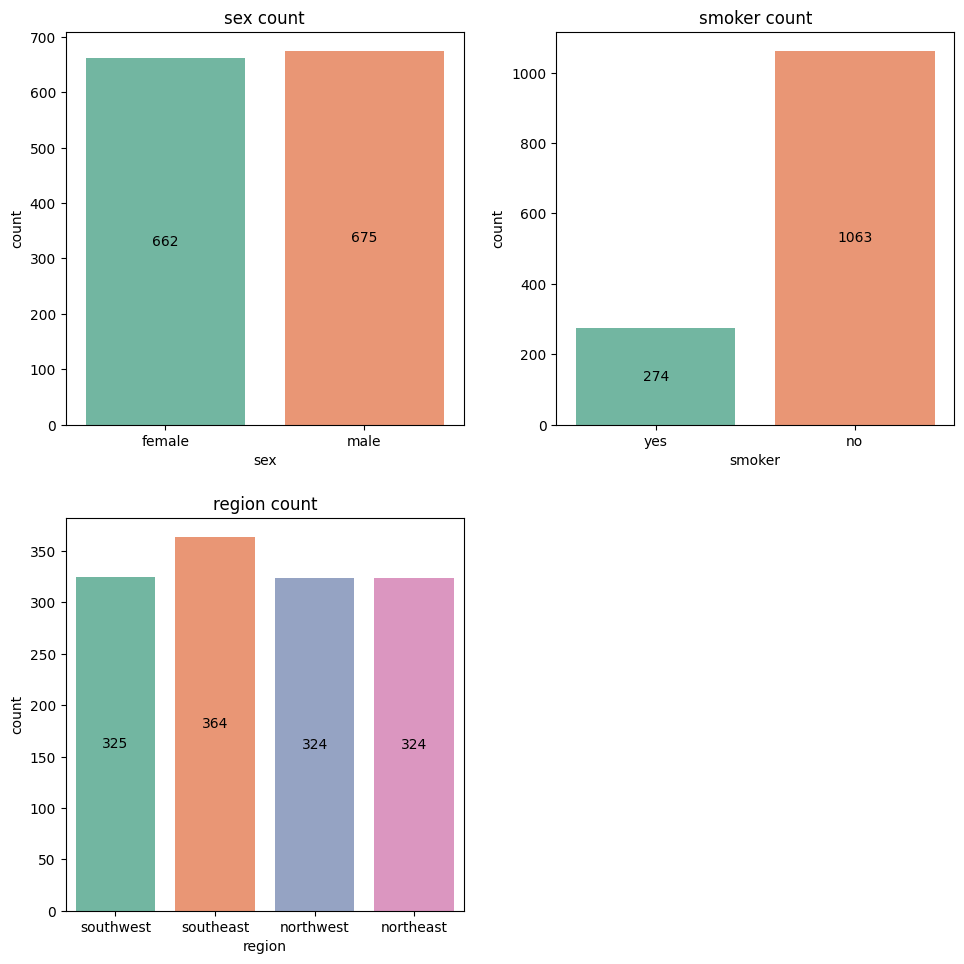

In [16]:
plt.figure(figsize = (10,10))
for i, col in  enumerate(cat_cols):
  plt.subplot(2,2,i+1)
  ax = sns.countplot(x = df[col], palette = 'Set2') # Assign the Axes object directly
  for container in ax.containers:
    ax.bar_label(container, label_type = 'center') # Apply bar_label to each container
  plt.title(f'{col} count')
  plt.tight_layout(pad = 2)
plt.show()

Categorical vs Target

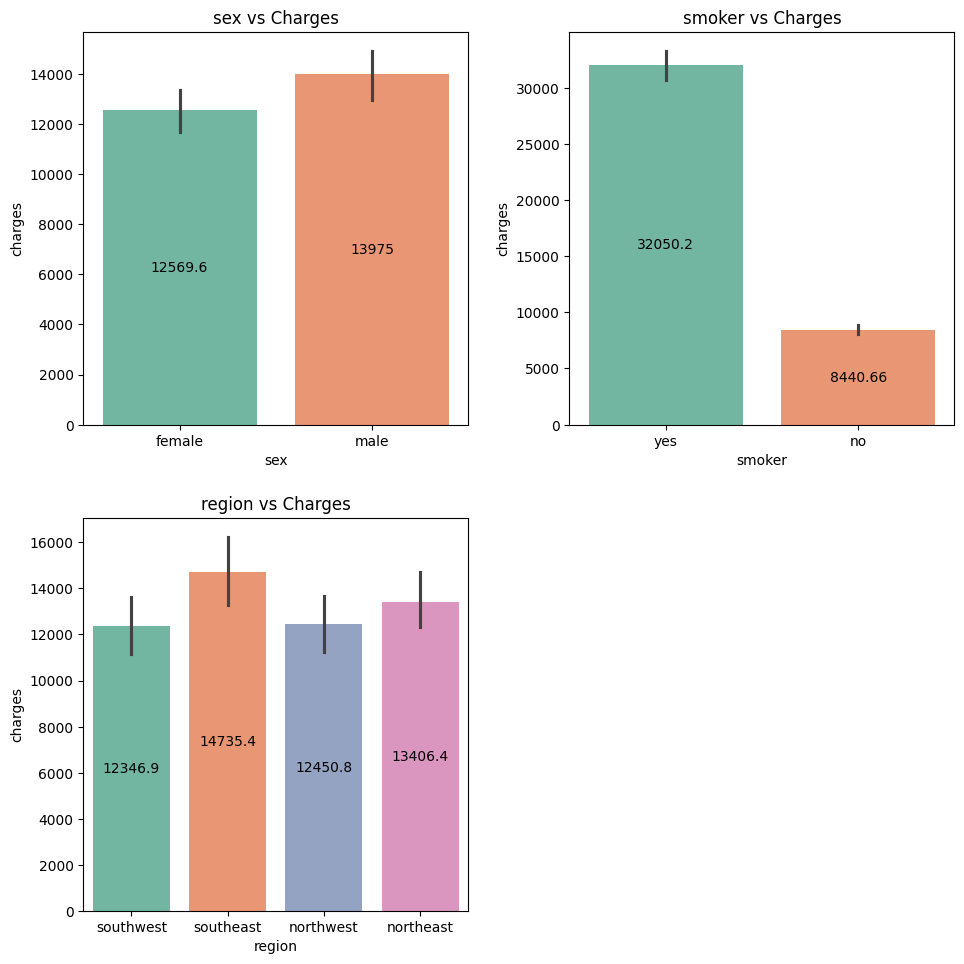

In [17]:
plt.figure(figsize = (10,10))
for i, col in  enumerate(cat_cols):
  plt.subplot(2,2,i+1)
  ax = sns.barplot(x = df[col],y = df['charges'] ,palette = 'Set2') # Assign the Axes object directly
  for container in ax.containers:
    ax.bar_label(container, label_type = 'center') # Apply bar_label to each container
  plt.title(f'{col} vs Charges')
  plt.tight_layout(pad = 2)
plt.show()

Observe:
- Male incur a higher medical charges as compared to feamle
- Smokers incur higher medical charges as compared to non smokers
- South Eastern region patients incur higher medical bills than the patients from the other regions

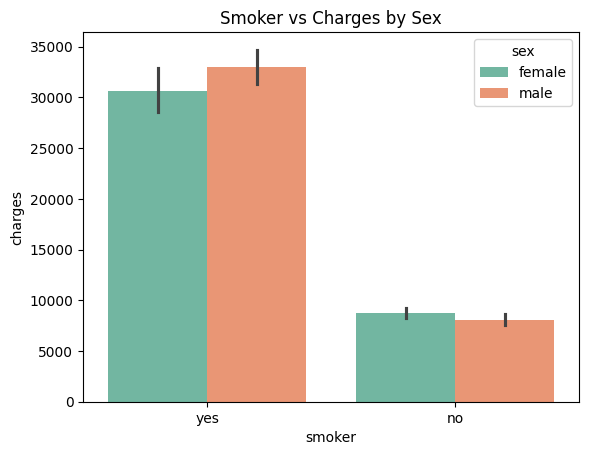

In [18]:
sns.barplot(data = df, x = 'smoker', y = 'charges', hue = 'sex', palette = 'Set2')
plt.title('Smoker vs Charges by Sex')
plt.show()

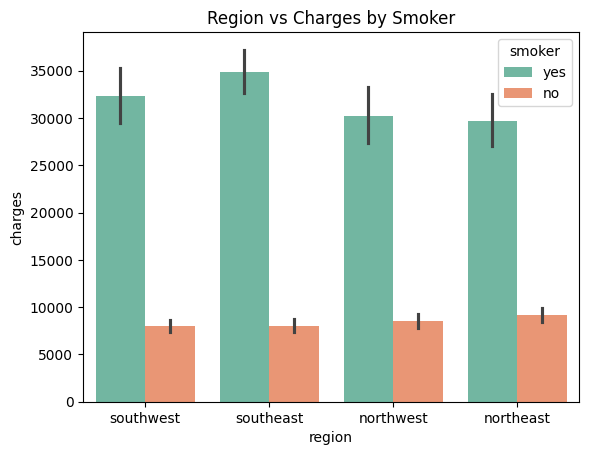

In [19]:
sns.barplot(data = df, x = 'region', y = 'charges', hue = 'smoker', palette = 'Set2')
plt.title('Region vs Charges by Smoker')
plt.show()

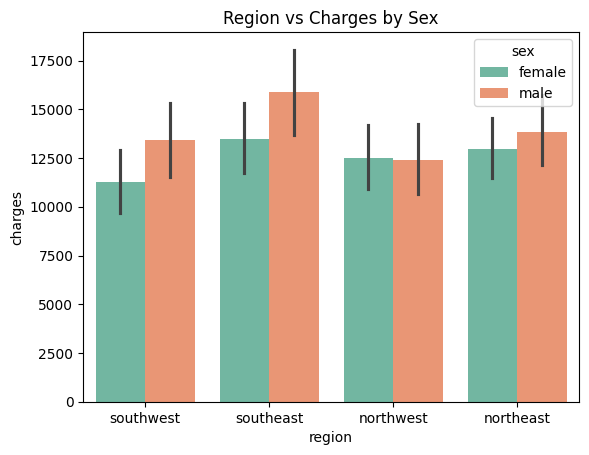

In [20]:
sns.barplot(data = df, x = 'region', y = 'charges', hue = 'sex', palette = 'Set2')
plt.title('Region vs Charges by Sex')
plt.show()

Observe:
- Most smokers were male
- Southeast region had the most smokers as compared to all other regions
- Southeast region had more males than female

Correlation Analysis

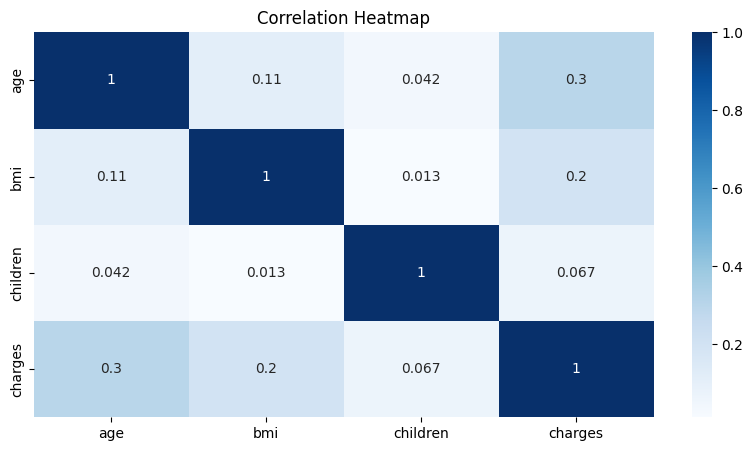

In [21]:
corr = df[num_cols].corr()
plt.figure(figsize = (10,5))
sns.heatmap(corr, annot = True, cmap = 'Blues')
plt.title('Correlation Heatmap')
plt.show()

The numerical features are weakly correlated to the target variable

### Feature Engineering

In [22]:
bmi_cat = pd.cut(df['bmi'], bins=[0, 18.5, 24.9, 29.9, np.inf], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
age_cat = pd.cut(df['age'], bins = [13,19,30,45,60,np.inf], labels = ['Teenager','Young adult','Adult','Middle-aged adult', 'Aged adult'])
df['bmi_cat'] = bmi_cat
df['age_cat'] = age_cat

In [23]:
## encode numerical features
df1 = df.copy(deep = True)

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
le = LabelEncoder()
ohe = OneHotEncoder(
    sparse_output=False,
    drop='first',
    handle_unknown='ignore'
)

df1['sex'] = le.fit_transform(df1['sex'])
df1['smoker'] = le.fit_transform(df1['smoker'])
df1['region'] = ohe.fit_transform(df1[['region']])
df1['bmi_cat'] = ohe.fit_transform(df1[['bmi_cat']])
df1['age_cat'] = ohe.fit_transform(df1[['age_cat']])

In [24]:
df1.head()

,age,sex,bmi,children,smoker,region,charges,bmi_cat,age_cat
0,19,0,27.900,0,1,0.0,16884.92400,0.0,0.0
1,18,1,33.770,1,0,0.0,1725.55230,1.0,0.0
2,28,1,33.000,3,0,0.0,4449.46200,1.0,0.0
3,33,1,22.705,0,0,1.0,21984.47061,0.0,0.0
4,32,1,28.880,0,0,1.0,3866.85520,0.0,0.0


### Feature selection

In [25]:
X = df1.drop('charges', axis = 1)
y = df1['charges']

score = SelectKBest(score_func = mutual_info_regression, k = 'all')
score.fit(X,y)


feature_scores = pd.DataFrame(score.scores_, index = X.columns, columns = ['score'])

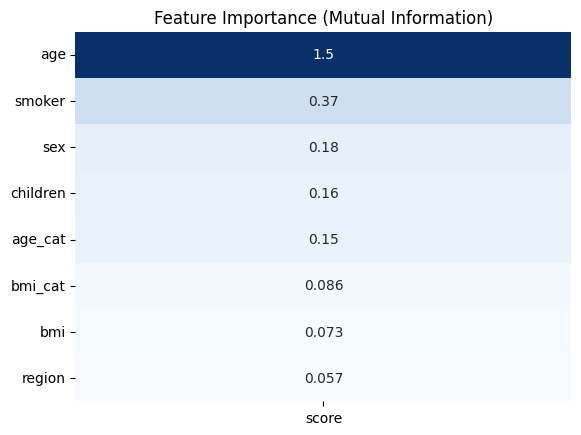

In [26]:
sns.heatmap(feature_scores.sort_values(by = 'score', ascending = False), annot = True, cmap = 'Blues', cbar = False)
plt.title('Feature Importance (Mutual Information)')
plt.show()

bmi_cat, bmi and region have the least significance score. Meaning they will have less impact in the models prediction

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [28]:
extra_tree = ExtraTreesRegressor(n_estimators = 100, random_state = 42)
extra_tree.fit(X_train,y_train)

ExtraTreesRegressor(random_state=42)

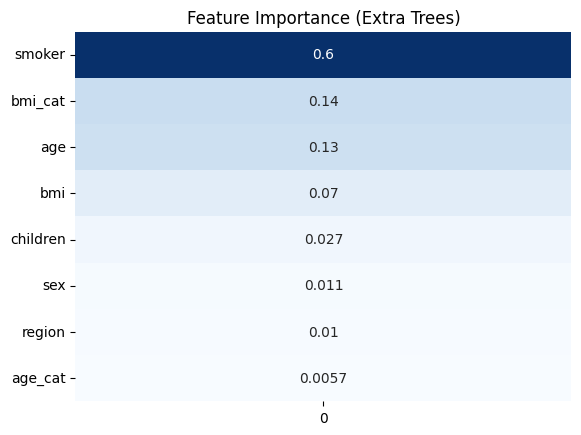

In [29]:
feature_importance = extra_tree.feature_importances_
feature_importance = pd.Series(feature_importance, index = X.columns)

sns.heatmap(feature_importance.sort_values(ascending = False).to_frame(), annot = True, cmap = 'Blues', cbar = False)
plt.title('Feature Importance (Extra Trees)')
plt.show()

Mutual information evaluates significance of features independently while Extra trees builds trees with all the features capturing feature interactions.

Region, age_cat appear to be the least significance

In [30]:
##drop the less significant features
X_train.drop(columns = ['region', 'age_cat'], axis = 1, inplace = True)
X_test.drop(columns = ['region', 'age_cat'], axis = 1, inplace = True)

### Scaling

In [31]:
from sklearn.compose import ColumnTransformer

outlier = ['bmi']
normal_features = ['age', 'children']

preprocessor = ColumnTransformer(
    transformers = [
        ('robust', RobustScaler(), outlier),
        ('standard', MinMaxScaler(), normal_features)
    ],
    remainder = 'passthrough'
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)


### Model Training

In [32]:
models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'Decision Tree': DecisionTreeRegressor(max_depth = 4, min_samples_split=3,random_state = 42),
    'SVR': SVR(kernel = 'rbf', gamma = 'auto'),
    'KNN': KNeighborsRegressor(n_neighbors = 5),
    'Random Forest': RandomForestRegressor(max_depth = 4,min_samples_split=3, random_state = 42),
    'Gradient Boosting': GradientBoostingRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'XGBoost': XGBRegressor()
}

df_results = pd.DataFrame(columns = ['Model', 'MAE', 'MSE', 'RMSE', 'R2'])

for regressor in models:
  print('\nRunning: ',regressor)
  models[regressor].fit(X_train_scaled, y_train)
  y_pred = models[regressor].predict(X_test_scaled)
  y_train_pred = models[regressor].predict(X_train_scaled)

  mae_train = round(mean_absolute_error(y_train, y_train_pred),3)
  mse_train = round(mean_squared_error(y_train, y_train_pred),3)
  rmse_train = round(np.sqrt(mse_train),3)
  r2_train = round(r2_score(y_train, y_train_pred),2)


  mae_test = round(mean_absolute_error(y_test, y_pred),3)
  mse_test = round(mean_squared_error(y_test, y_pred),3)
  rmse_test = round(np.sqrt(mse_test),3)
  r2_test = round(r2_score(y_test, y_pred),2)
  print('Training')
  print(f'MAE: {mae_train}')
  print(f'MSE: {mse_train}')
  print(f'RMSE: {rmse_train}')
  print(f'R2: {r2_train}')

  print('Testing')
  print(f'MAE: {mae_test}')
  print(f'MSE: {mse_test}')
  print(f'RMSE: {rmse_test}')
  print(f'R2: {r2_test}')
  print('*'* 20)

  dict_row = {'Model':regressor, 'MAE':mae_test, 'MSE':mse_test, 'RMSE':rmse_test, 'R2':r2_test}
  df_results = pd.concat([df_results, pd.DataFrame([dict_row])], ignore_index = True)



Running:  Linear Regression
Training
MAE: 4216.389
MSE: 36221899.115
RMSE: 6018.463
R2: 0.74
Testing
MAE: 4311.274
MSE: 36127108.104
RMSE: 6010.583
R2: 0.8
********************

Running:  Lasso
Training
MAE: 4215.711
MSE: 36221942.036
RMSE: 6018.467
R2: 0.74
Testing
MAE: 4311.012
MSE: 36135385.669
RMSE: 6011.272
R2: 0.8
********************

Running:  Ridge
Training
MAE: 4217.052
MSE: 36226254.908
RMSE: 6018.825
R2: 0.74
Testing
MAE: 4322.453
MSE: 36337017.893
RMSE: 6028.019
R2: 0.8
********************

Running:  Decision Tree
Training
MAE: 2567.47
MSE: 19819471.478
RMSE: 4451.906
R2: 0.86
Testing
MAE: 2621.312
MSE: 18886631.25
RMSE: 4345.875
R2: 0.9
********************

Running:  SVR
Training
MAE: 8099.57
MSE: 150392704.949
RMSE: 12263.47
R2: -0.1
Testing
MAE: 9275.749
MSE: 207894187.365
RMSE: 14418.536
R2: -0.13
********************

Running:  KNN
Training
MAE: 2360.11
MSE: 18037823.094
RMSE: 4247.096
R2: 0.87
Testing
MAE: 2919.419
MSE: 28545465.521
RMSE: 5342.796
R2: 0.84
*******

In [33]:
## hyperparameter tuning
model_params = {
    'Decision Tree': {
        'model': DecisionTreeRegressor(),
        'params': {
             'max_depth' : [3,4,7,8],
             'min_samples_split': [3,4,5],
        }
    },

    'Random Forest': {
        'model': RandomForestRegressor(),
        'params': {
            'n_estimators': [100,300,800],
            'max_depth' : [3,4,7,8],
            'min_samples_split': [3,4,5],
        }
    },

    'Gradient Boosting': {
        'model': GradientBoostingRegressor(),
        'params': {
            'n_estimators': [100,300,800],
            'learning_rate': [0.01,0.05,0.1],
            'max_depth' : [3,4,7,8],
            'min_samples_split': [3,4,5],
        }
    },

    'XGBoost': {
        'model': XGBRegressor(),
        'params': {
            'n_estimators': [100,300,800],
            'learning_rate': [0.01,0.05,0.1],
            'max_depth' : [3,4,7,8],
            'colsample_bytree':[0.4,0.6,1]
        }
    }
}



In [34]:
score = []
for name,model in model_params.items():
    model =RandomizedSearchCV(estimator = model['model'], param_distributions = model['params'], cv = 5, n_iter = 10)
    model.fit(X_train_scaled, y_train)
    score.append({
        'model': name,
        'best_score': model.best_score_,
        'best_params': model.best_params_
    })


result = pd.DataFrame(score, columns = ['model', 'best_score', 'best_params'])
result

,model,best_score,best_params
0,Decision Tree,0.833364,"{'min_samples_split': 5, 'max_depth': 4}"
1,Random Forest,0.836983,"{'n_estimators': 300, 'min_samples_split': 3, ..."
2,Gradient Boosting,0.842684,"{'n_estimators': 100, 'min_samples_split': 5, ..."
3,XGBoost,0.841959,"{'n_estimators': 800, 'max_depth': 3, 'learnin..."


Scores did not improve with hyperparameters. It could be because the search space is small because the data is small

In [35]:
pd.set_option('display.float_format', '{:.3f}'.format)
df_results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,4311.274,36127108.104,6010.583,0.800
1,Lasso,4311.012,36135385.669,6011.272,0.800
2,Ridge,4322.453,36337017.893,6028.019,0.800
3,Decision Tree,2621.312,18886631.250,4345.875,0.900
4,SVR,9275.749,207894187.365,14418.536,-0.130
5,KNN,2919.419,28545465.521,5342.796,0.840
6,Random Forest,2480.310,18165300.757,4262.077,0.900
7,Gradient Boosting,2502.379,18222673.751,4268.802,0.900
8,AdaBoost,4123.000,25198472.000,5019.808,0.860
9,XGBoost,2773.519,24088031.423,4907.956,0.870


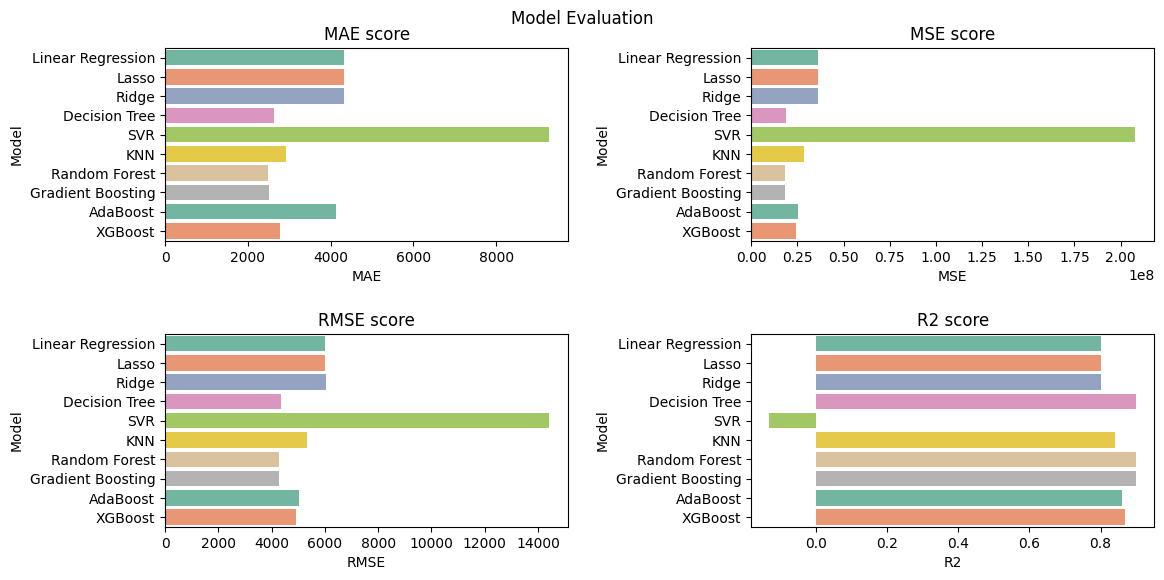

In [36]:
plt.figure(figsize = (12,6))
for i, col in enumerate(df_results[['MAE','MSE','RMSE','R2']]):
  plt.subplot(2,2,i+1)
  sns.barplot(data = df_results, x = col, y = 'Model', palette='Set2')
  plt.title(f'{col} score')

plt.tight_layout(pad = 2)
plt.suptitle('Model Evaluation')
plt.show()

Gradient Boosting and Random Forest performed relatively well as compared to the rest of the models even without hyperparameter tuning but Random forest  is the best of all

In [37]:
## Gradient boosting

model = RandomForestRegressor(max_depth = 4,min_samples_split=3, random_state = 42)
model.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=4, min_samples_split=3, random_state=42)

In [38]:
y_pred = model.predict(X_test_scaled)

In [41]:
rf_mae = mean_absolute_error(y_test, y_pred)
rf_mse = mean_squared_error(y_test, y_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred)

print(f'MAE: {rf_mae:.2f}')
print(f'MSE: {rf_mse:.2f}')
print(f'RMSE: {rf_rmse:.2f}')
print(f'R2: {rf_r2:.2f}')

MAE: 2480.31
MSE: 18165300.76
RMSE: 4262.08
R2: 0.90


In [42]:
df_analysis = pd.DataFrame({'Actual':y_test, 'Predicted':y_pred})
df_analysis.head()

,Actual,Predicted
900,8688.859,11234.261
1064,5708.867,7477.127
1256,11436.738,11290.521
298,38746.355,41385.819
237,4463.205,6553.317


In [43]:
df_analysis['Residual'] = df_analysis['Actual'] - df_analysis['Predicted']
df_analysis

,Actual,Predicted,Residual
900,8688.859,11234.261,-2545.402
1064,5708.867,7477.127,-1768.260
1256,11436.738,11290.521,146.217
298,38746.355,41385.819,-2639.464
237,4463.205,6553.317,-2090.112
...,...,...,...
534,13831.115,14408.756,-577.641
542,13887.204,14289.530,-402.326
760,3925.758,6680.636,-2754.878
1284,47403.880,45656.310,1747.570


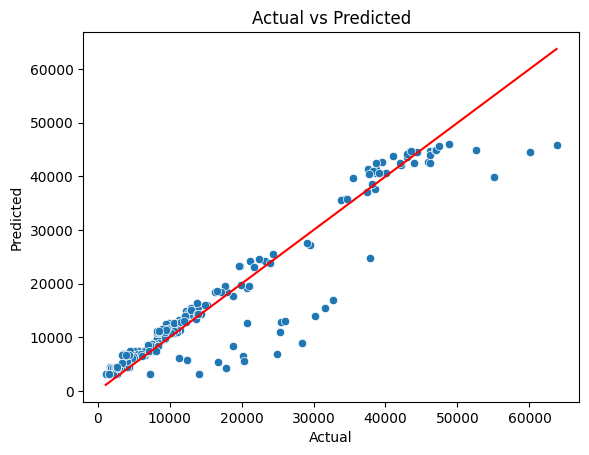

In [47]:
sns.scatterplot(data = df_analysis, x = 'Actual', y = 'Predicted', palette = 'Set2')
plt.plot([min(df_analysis['Actual']), max(df_analysis['Actual'])], [min(df_analysis['Actual']), max(df_analysis['Actual'])], color = 'red')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

The model performs well on predicting low and medium prices but fails on expensive medical prices

Text(0.5, 0, 'Predicted')

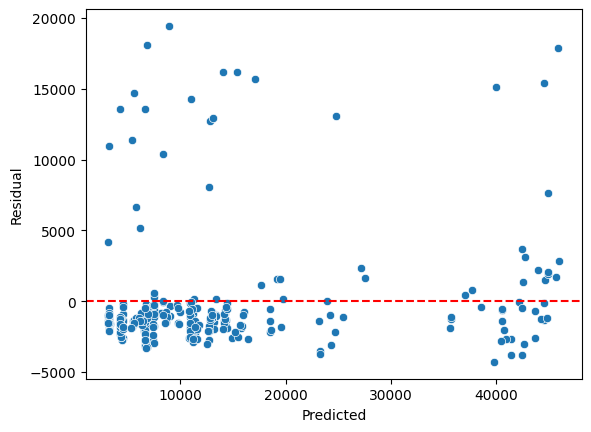

In [48]:
## Residuals vs predicted
sns.scatterplot(data = df_analysis, x = 'Predicted', y = 'Residual', palette = 'Set2')
plt.axhline(y = 0, color = 'red', linestyle = '--')
plt.xlabel('Predicted')

Most of the predictions are far of by + or - (5000). But the model struggles to predict some of the extremely low and extremely high prices

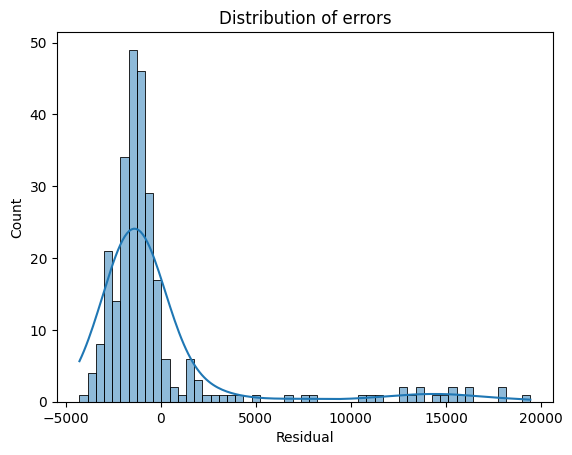

In [49]:
sns.histplot(data = df_analysis, x= 'Residual', kde = True, palette = 'Set2')
plt.title('Distribution of errors')
plt.show()

In [50]:
## worst predictions
df_analysis['absolute_error'] = abs(df_analysis['Residual'])

In [51]:
df_analysis.sort_values(by = 'absolute_error', ascending = False).head(10)

,Actual,Predicted,Residual,absolute_error
987,28340.189,8894.219,19445.970,19445.970
637,24915.046,6845.574,18069.472,18069.472
543,63770.428,45918.004,17852.424,17852.424
573,31620.001,15395.286,16224.715,16224.715
115,30259.996,14071.655,16188.340,16188.340
128,32734.186,17047.686,15686.501,15686.501
1230,60021.399,44581.030,15440.369,15440.369
819,55135.402,39970.432,15164.970,15164.970
291,20277.808,5561.680,14716.128,14716.128
925,25333.333,11045.390,14287.943,14287.943
